<a href="https://colab.research.google.com/github/SmritiChettri/ML-Oracle/blob/main/oracle_AI_foundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning Process**


*   Loading Data

*   Preprocessing

*   Training a model
*   Evaluating a model


*   Making predictions




In [ ]:
#import necessary libraries
import pandas as pd
from sklearn.linear_model import LogisticRegression

In [ ]:
# loading the dataseet and displaying the first few rowa
iris_data =pd.read_csv("iris.csv")
iris_data.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [ ]:
# split data into features (X) and labels (Y)
X = iris_data.drop(columns = ["variety"])
Y = iris_data["variety"]

In [ ]:
X.head()

,sepal.length,sepal.width,petal.length,petal.width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
iris_data.columns

Index(['sepal.length', 'sepal.width', 'petal.length', 'petal.width',
       'variety'],
      dtype='object')

In [ ]:
# create a ML model
model = LogisticRegression()

In [ ]:
# train a model
model.fit(X.values, Y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# predict using trained model
predictions = model.predict([[5.1, 3.5, 1.4, 0.2]])

In [ ]:
print(predictions)

['Setosa']


## **New**

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


In [ ]:
iris_data = pd.read_csv("iris.csv")
iris_data.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [ ]:
X = iris_data.drop(columns = ["variety"])
Y = iris_data["variety"]

In [ ]:
# splitting the data into training and testing set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
# standardize the features
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.fit_transform(X_test)


In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train_scaled, Y_train)

LogisticRegression()

In [ ]:
Y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.9666666666666667


In [ ]:
# sample new data for prediction
new_data = np.array([[5.1, 3.5, 1.4, 0.2],
                     [6.3, 2.9, 5.6, 1.8],
                     [4.9, 3.0, 1.4, 0.2]])

In [ ]:
# standardize the new data
new_data_scaled = scalar.transform(new_data)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
predictions = model.predict(new_data_scaled)

In [ ]:
print("Predictions: ", predictions)

predictions:  ['Setosa' 'Virginica' 'Setosa']


### Classification with multilayer perceptron

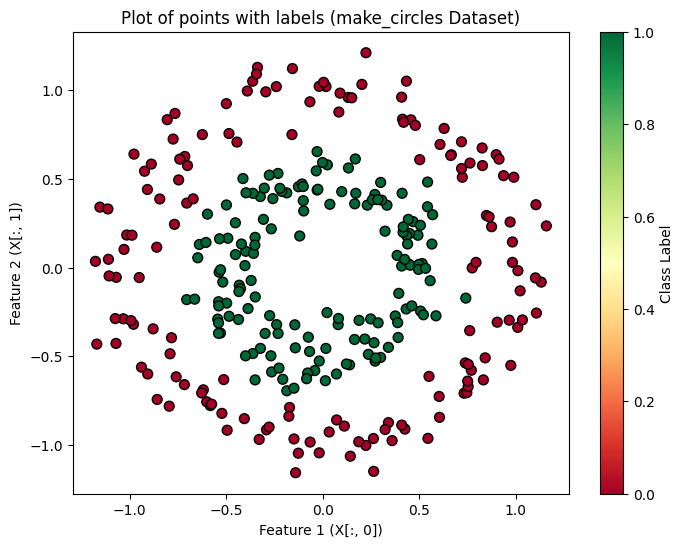

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
# generate synthetic data (circles)
x, y = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=0)

#plot the points with their labels
plt.figure(figsize=(8, 6))
plt.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.RdYlGn, edgecolors='k', marker="o", s=50)
plt.xlabel("Feature 1 (X[:, 0])")
plt.ylabel("Feature 2 (X[:, 1])")
plt.title("Plot of points with labels (make_circles Dataset)")
plt.colorbar(label="Class Label")
plt.show()


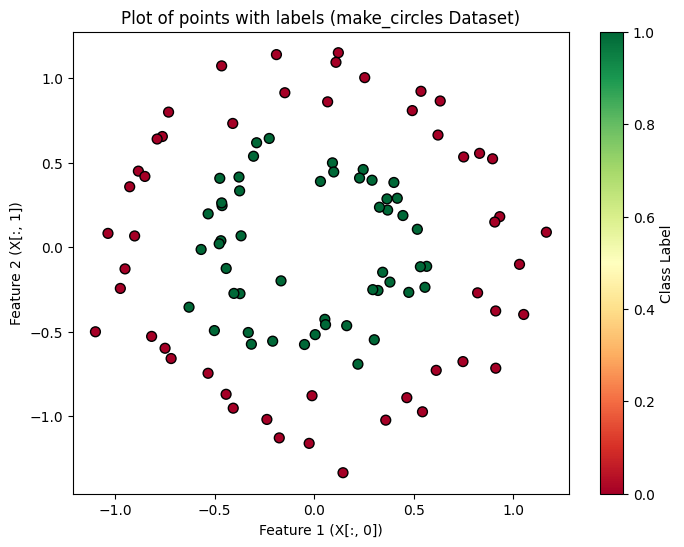

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
# generate synthetic data (circles)
x, y = make_circles(n_samples=100, noise=0.1, factor=0.5, random_state=0)

#plot the points with their labels
plt.figure(figsize=(8, 6))
plt.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.RdYlGn, edgecolors='k', marker="o", s=50)
plt.xlabel("Feature 1 (X[:, 0])")
plt.ylabel("Feature 2 (X[:, 1])")
plt.title("Plot of points with labels (make_circles Dataset)")
plt.colorbar(label="Class Label")
plt.show()


## Interactive Classification

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.neural_network import MLPClassifier
import ipywidgets as widgets
from IPython.display import display
from ipywidgets import interactive

#function to update and display plot
def update_plot(hidden_layer_size):
  clf = MLPClassifier(hidden_layer_sizes=(hidden_layer_size,), activation="relu", max_iter = 3000, random_state=1)

  X, y = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=0)
  #fit classifier into data
  clf.fit(X, y)

  #create grid of points for visualization
  #these are 1D arrays of 100 values each, representing the x and y coordinates of the grid

  x_vals = np.linspace(X[:, 0].min() - 0.1, X[:, 0].max() + 0.1, 100)
  y_vals = np.linspace(X[:, 1].min() - 0.1, X[:, 1].max() + 0.1, 100)

  # the resulting x_plane and Y_plane are both 100x100 arrays
  #representing a grid of 10,000 points
  X_plane, Y_plane = np.meshgrid(x_vals, y_vals)

  #grid_points is a single 2D array (grid_points) of shape (1000,2),
  #where each row represents a point in a grid
  grid_points = np.column_stack((X_plane.ravel(), Y_plane.ravel()))

  #predict class labels for the grid points (for decision boundry)
  Z = clf.predict(grid_points)

  #Z.reshape(X_plane.shape) reshapes Z into a 100x100 array
  Z =Z.reshape(X_plane.shape)



  #predict class layer for original data points
  y_pred = clf.predict(X)

  #clear previous plot
  plt.clf()

  #pl0t the decision boundry
  #it is often used to visualize the decision boundry of a model by plotting
  # the predicted class probabilities or labels across a grid of points
  plt.contourf(X_plane, Y_plane, Z, levels=[-0.5, 0.5, 1.5], cmap=plt.cm.RdYlGn, alpha=0.6)

  #plot original data points with their predicted labels
  #seperate points for each predicted class
  class_0 = y_pred == 0 #indices of points predicted as class 0
  class_1 = y_pred == 1 #indices of points predicted as class 1

  plt.scatter(X[class_0, 0], X[class_0, 1], c="red", edgecolor="k", marker="o", s=50, label="Predicted Class 0")
  plt.scatter(X[class_1, 0], X[class_1, 1], c="green", edgecolor="k", marker="o", s=50, label="Predicted Class 1")

  #add labels and title
  plt.title(f"Decision Boundry and predicted labels (Hidden Layer Size = {hidden_layer_size})")
  plt.xlabel("Feature 1")
  plt.ylabel("Feature 2")
  plt.legend()
  plt.show()

#create slider for hidden layer size
hidden_layer_size_slider = widgets.IntSlider(value=1, min=1, max=10, step=1, description="Hidden Layer Size")

#create interactive widget
interactive_plot = interactive(update_plot, hidden_layer_size=hidden_layer_size_slider)

#display widgets
display(interactive_plot)

interactive(children=(IntSlider(value=1, description='Hidden Layer Size', max=10, min=1), Output()), _dom_clas…